# **Temporal Window**

### **Description**

Injury events are influenced by multiple factors across different time scales. However, many sports follow a highly periodized structure, in which athletes are exposed to different training stimuli over relatively short periods, typically no longer than a few weeks. For this reason, our model focuses on the impact of short-term training variations on injury risk, and we defined a temporal window of three weeks.

In the following section, we analyze variables directly related to training load within this temporal window in relation to injury events. The main goal is to identify potential patterns showing how training load influences the overall occurrence of injury, while assuming unbiased athlete profiles.

In [16]:
# Dependencies
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

### **Data Loading**

It should be remarked that for all EDA sections, week approach will be conducted. The loaded dataset is already processed and contains this temporal window of three weeks. 

For the week approach, the count goes from 0 (the week before the event day) to 2 (starting three weeks before the event day). 

In [17]:
# Paths and Dataframe loading
file_path = '../Dataset/week_approach_maskedID_timeseries.csv'
df = pd.read_csv(file_path)

# Isolating injury and healthy data
injury_df = df[df['injury'] == 1]
healthy_df = df[df['injury'] == 0]

### **Total and Relative Mileage Analysis**

In [18]:
# Total Mileage analysis
kms_cols = ['total kms', 'total kms.1', 'total kms.2']

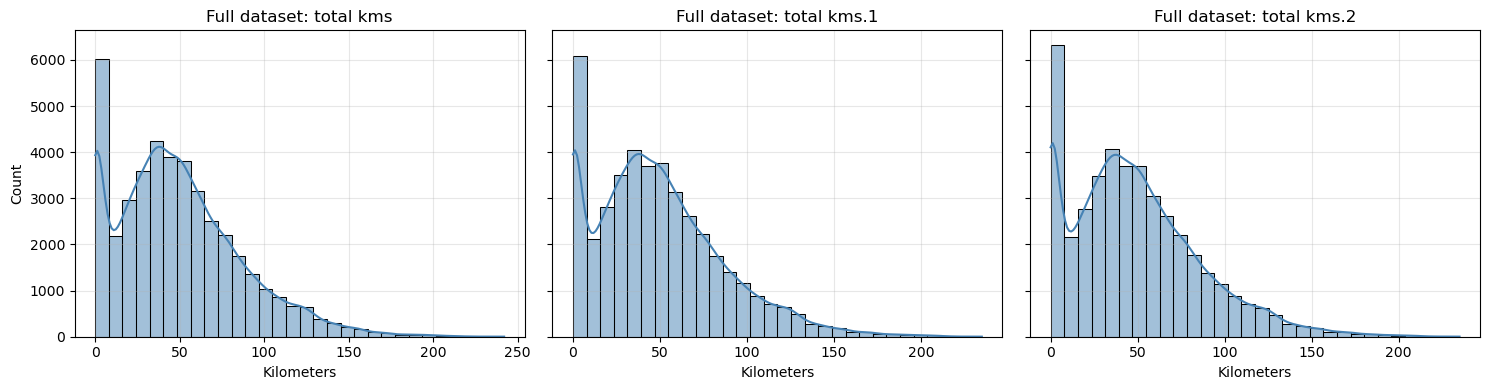

In [19]:
# Histogram plot for not injured data
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, kms_cols):
    sns.histplot(
        data=healthy_df,
        x=col,
        bins=30,
        kde=True,
        color='steelblue',
        ax=ax
    )
    ax.set_title(f'Full dataset: {col}')
    ax.set_xlabel('Kilometers')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

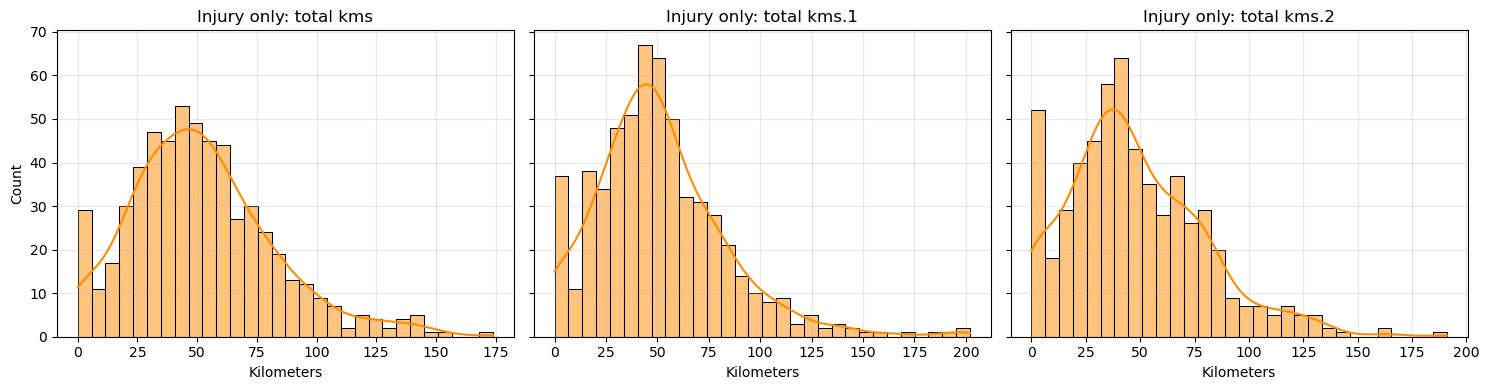

In [20]:
# Histogram plot for injured data
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, kms_cols):
    sns.histplot(
        data=injury_df,
        x=col,
        bins=30,
        kde=True,
        color='darkorange',
        ax=ax
    )
    ax.set_title(f'Injury only: {col}')
    ax.set_xlabel('Kilometers')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The histograms for both groups indicate that total mileage over the three-week window is concentrated at lower values, with a clear peak at zero that is more pronounced in the non-injured group. These zero values likely reflect athletes returning from periods of inactivity, when prior weekly mileage is minimal or absent.

In the injury group, the peak at zero is less prominent, suggesting that injuries tend to occur more often after at least two weeks of resumed training rather than immediately upon return. This pattern may help identify time windows of elevated injury risk during the reloading phase.

In [21]:
# Average and sparsity of both groups
healthy_stats = healthy_df[kms_cols].agg(['mean', 'std']).T
injury_stats = injury_df[kms_cols].agg(['mean', 'std']).T

healthy_stats.columns = ['mean_healthy', 'std_healthy']
injury_stats.columns = ['mean_injury', 'std_injury']

stats_compare = healthy_stats.join(injury_stats)
stats_compare = stats_compare.round(3)

print("Mean and STD comparison (healthy data vs injury data):")
print(stats_compare)


Mean and STD comparison (healthy data vs injury data):
             mean_healthy  std_healthy  mean_injury  std_injury
total kms          49.512       36.796       51.856      30.109
total kms.1        49.229       36.890       51.189      32.014
total kms.2        48.822       37.032       47.692      31.393


We observe that total mileage is generally higher and less sparse in the injury group than in the healthy group, suggesting a potential association between sharper volume progression and injury occurrence. In addition, during the earliest week in the window (total kms.2), the mean mileage in injured cases is slightly lower than in healthy cases, whereas in the two weeks immediately preceding injury the mean mileage increases. This pattern supports the hypothesis that a relatively abrupt rise in training load may contribute to injury risk.

In [22]:
# Relative mileage columns (week 0 / week 1; week 0 / week 2; week 1 / week 2 )
rel_cols = ['rel total kms week 0_1', 'rel total kms week 0_2', 'rel total kms week 1_2']

# Filter out rows where denominator weeks are zero and also remove zero relative values
rel_healthy = healthy_df.loc[
    (healthy_df['total kms.1'] > 0) &
    (healthy_df['total kms.2'] > 0)
].copy()

rel_injury = injury_df.loc[
    (injury_df['total kms.1'] > 0) &
    (injury_df['total kms.2'] > 0)
].copy()

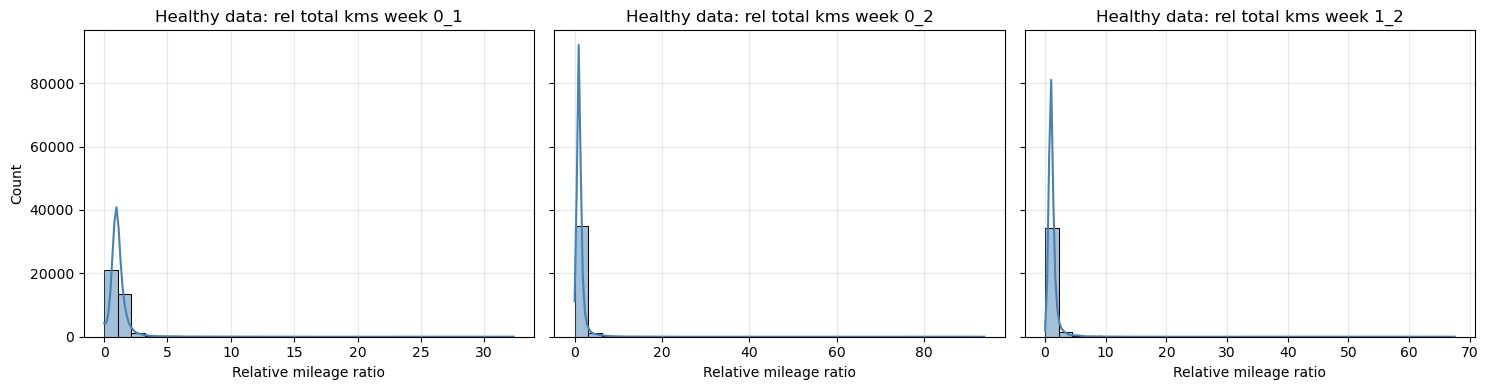

In [23]:
# Histogram plot for healthy data
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, rel_cols):
    sns.histplot(
        data=rel_healthy,
        x=col,
        bins=30,
        kde=True,
        color='steelblue',
        ax=ax
    )
    ax.set_title(f'Healthy data: {col}')
    ax.set_xlabel('Relative mileage ratio')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

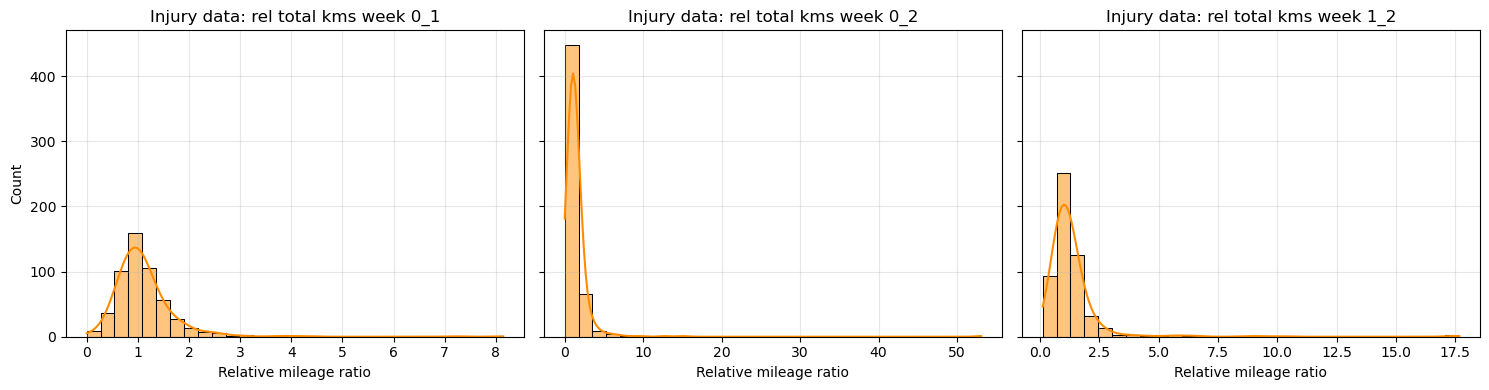

In [24]:
# Histogram plot for injury data
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, rel_cols):
    sns.histplot(
        data=rel_injury,
        x=col,
        bins=30,
        kde=True,
        color='darkorange',
        ax=ax
    )
    ax.set_title(f'Injury data: {col}')
    ax.set_xlabel('Relative mileage ratio')
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Relative Mileage Loading in Injury**

To further examine how increases in training load may influence injury risk, we apply a threshold-based filter to the relative mileage variables, comparing healthy and injury cases.

In [25]:
# Filtering by threshold (per column)
threshold = 1.25 # Sufficiently large ratio
healthy_above = {col: rel_healthy[rel_healthy[col] > threshold].copy() for col in rel_cols}
injury_above = {col: rel_injury[rel_injury[col] > threshold].copy() for col in rel_cols}

# Combined filter: any relative-mileage column above threshold
healthy_any_above = rel_healthy[rel_healthy[rel_cols].gt(threshold).any(axis=1)].copy()
injury_any_above = rel_injury[rel_injury[rel_cols].gt(threshold).any(axis=1)].copy()

# Quick summary
print(f"Threshold = {threshold}\n")

for col in rel_cols:
    h_n = len(healthy_above[col])
    i_n = len(injury_above[col])
    h_pct = 100 * h_n / len(rel_healthy) if len(rel_healthy) else 0
    i_pct = 100 * i_n / len(rel_injury) if len(rel_injury) else 0
    print(f"{col}:")
    print(f"  Healthy > {threshold}: {h_n} ({h_pct:.2f}%)")
    print(f"  Injury  > {threshold}: {i_n} ({i_pct:.2f}%)")

print("\nAny relative column > threshold:")
print(f"  Healthy: {len(healthy_any_above)} ({100*len(healthy_any_above)/len(rel_healthy):.2f}%)")
print(f"  Injury : {len(injury_any_above)} ({100*len(injury_any_above)/len(rel_injury):.2f}%)")

Threshold = 1.25

rel total kms week 0_1:
  Healthy > 1.25: 10112 (27.69%)
  Injury  > 1.25: 144 (27.12%)
rel total kms week 0_2:
  Healthy > 1.25: 11760 (32.21%)
  Injury  > 1.25: 195 (36.72%)
rel total kms week 1_2:
  Healthy > 1.25: 10918 (29.90%)
  Injury  > 1.25: 198 (37.29%)

Any relative column > threshold:
  Healthy: 19879 (54.44%)
  Injury : 324 (61.02%)


We observe a higher prevalence of cases above the training-load increase threshold in the injury group overall. The week-to-week change from the previous week to the week before that is very similar across groups, with a slight advantage in the healthy group. However, in the other relative mileage comparisons, the injury group shows a clearer predominance of higher load increases. This pattern supports the hypothesis that sharper rises in total mileage are associated with greater injury risk.

### **Total Mileage versus Perceived Recovery in Injury**

In [26]:
injury_long = pd.concat([
pd.DataFrame({
"week_scenario": "3 weeks before (week 2)",
"perceived_recovery": injury_df["avg recovery.2"],
"total_kms": injury_df["total kms.2"]
}),
pd.DataFrame({
"week_scenario": "2 weeks before (week 1)",
"perceived_recovery": injury_df["avg recovery.1"],
"total_kms": injury_df["total kms.1"]
}),
pd.DataFrame({
"week_scenario": "1 week before (week 0)",
"perceived_recovery": injury_df["avg recovery"],
"total_kms": injury_df["total kms"]
})
], ignore_index=True).dropna(subset=["perceived_recovery", "total_kms"])

order = ["3 weeks before (week 2)", "2 weeks before (week 1)", "1 week before (week 0)"]

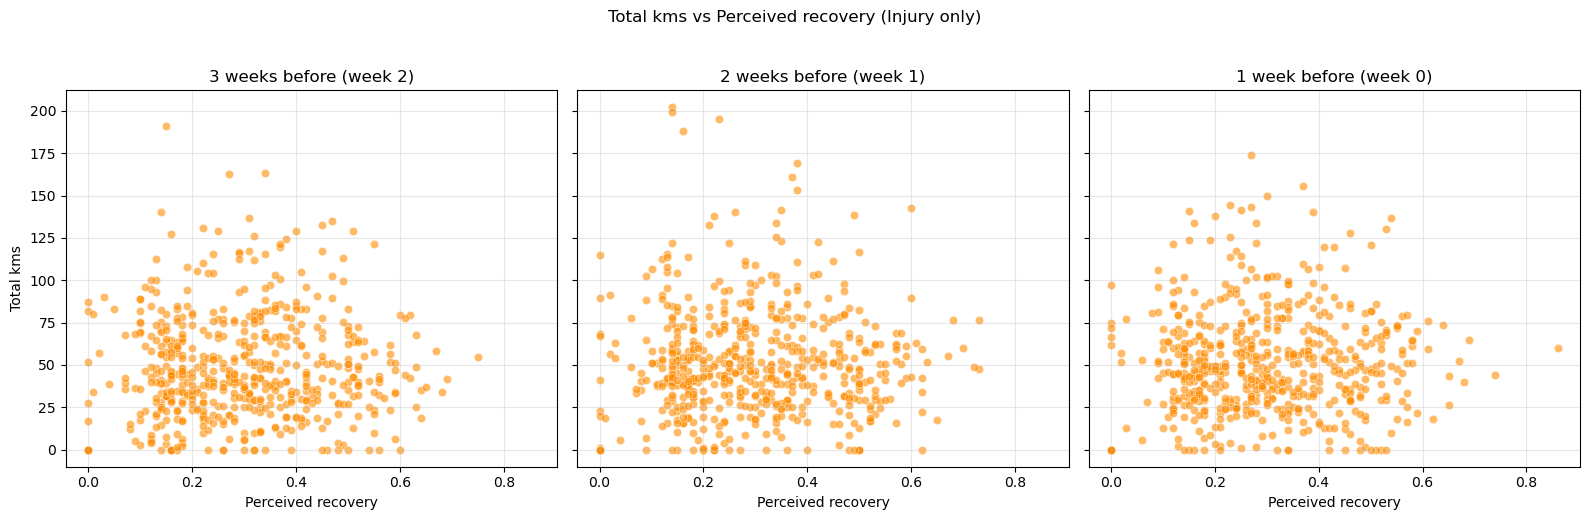

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

weekly_specs = [
    ("3 weeks before (week 2)", "avg recovery.2", "total kms.2"),
    ("2 weeks before (week 1)", "avg recovery.1", "total kms.1"),
    ("1 week before (week 0)", "avg recovery", "total kms"),
]

for ax, (title, rec_col, kms_col) in zip(axes, weekly_specs):
    sns.scatterplot(
        data=injury_df,
        x=rec_col,
        y=kms_col,
        alpha=0.6,
        color="darkorange",
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Perceived recovery")
    ax.set_ylabel("Total kms")
    ax.grid(True, alpha=0.3)

plt.suptitle("Total kms vs Perceived recovery (Injury only)", y=1.03)
plt.tight_layout()
plt.show()

Across the three weekly panels, points shift progressively to the right, suggesting that athletes report lower recovery in earlier weeks and higher perceived recovery closer to the injury event. This may indicate a mismatch between subjective recovery perception and actual readiness, where athletes feel increasingly recovered but remain at elevated risk. This pattern should be considered during modeling, potentially by assigning greater weight to objective workload indicators relative to subjective self-reports.

### **High Intensity Loading in Injury**

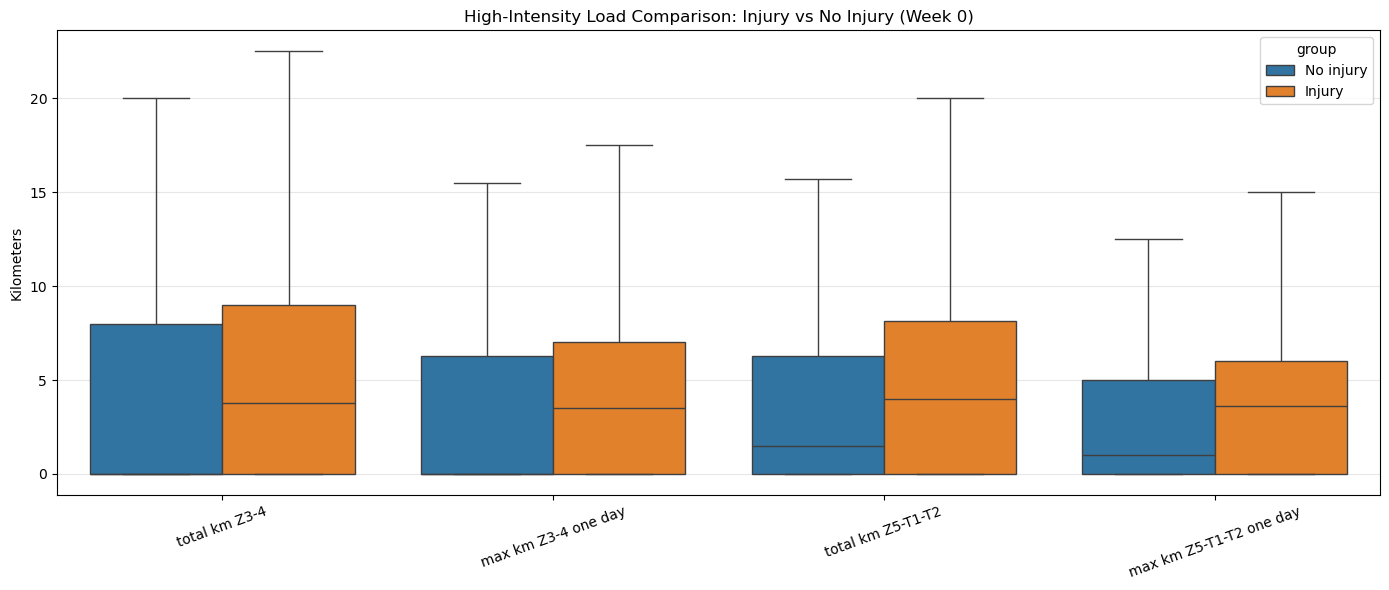

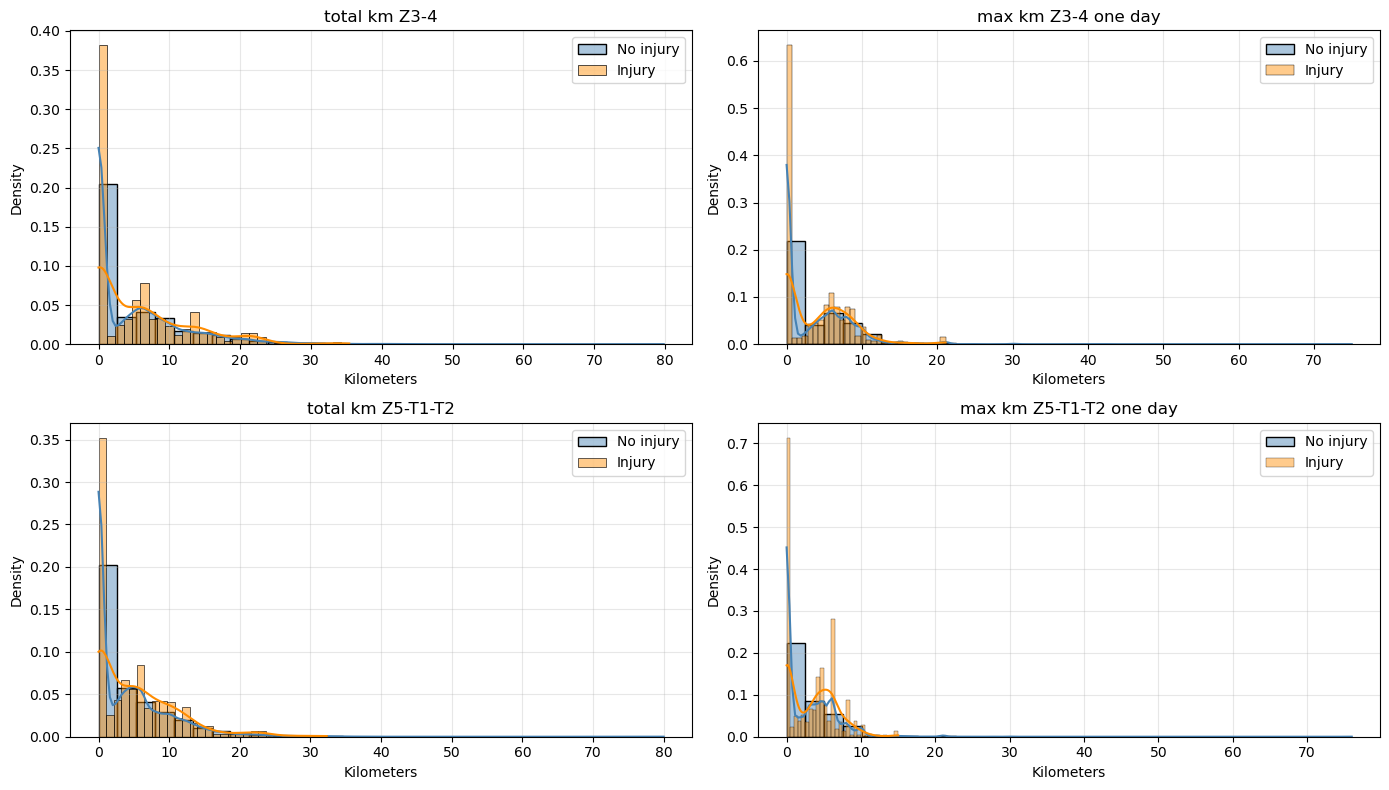

Summary statistics by injury status (0 = no injury, 1 = injury):
       total km Z3-4               max km Z3-4 one day                \
                mean    std median                mean    std median   
injury                                                                 
0              4.849  6.986    0.0               3.450  4.580    0.0   
1              5.593  6.881    3.8               3.939  4.379    3.5   

       total km Z5-T1-T2               max km Z5-T1-T2 one day                
                    mean    std median                    mean    std median  
injury                                                                        
0                  4.049  5.641    1.5                   2.717  3.552    1.0  
1                  5.179  5.860    4.0                   3.358  3.183    3.6  


In [ ]:
# Variables to compare (week 0)
hi_cols = [
    'total km Z3-4',
    'max km Z3-4 one day',
    'total km Z5-T1-T2',
    'max km Z5-T1-T2 one day'
]

# Build long dataframe for plotting
cmp_df = df[['injury'] + hi_cols].copy()
cmp_long = cmp_df.melt(
    id_vars='injury',
    value_vars=hi_cols,
    var_name='metric',
    value_name='value'
)

cmp_long['group'] = cmp_long['injury'].map({0: 'No injury', 1: 'Injury'})

# Boxplot comparison
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=cmp_long,
    x='metric',
    y='value',
    hue='group',
    showfliers=False
)
plt.title('High-Intensity Load Comparison: Injury vs No Injury (Week 0)')
plt.xlabel('')
plt.ylabel('Kilometers')
plt.xticks(rotation=20)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution comparison (histograms)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, hi_cols):
    sns.histplot(
        data=df[df['injury'] == 0],
        x=col,
        bins=30,
        stat='density',
        kde=True,
        color='steelblue',
        alpha=0.45,
        label='No injury',
        ax=ax
    )
    sns.histplot(
        data=df[df['injury'] == 1],
        x=col,
        bins=30,
        stat='density',
        kde=True,
        color='darkorange',
        alpha=0.45,
        label='Injury',
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel('Kilometers')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numeric summary
summary = (
    df.groupby('injury')[hi_cols]
      .agg(['mean', 'std', 'median'])
      .round(3)
)
print("Summary statistics by injury status (0 = no injury, 1 = injury):")
print(summary)

In the injury group, high-intensity workload variables are consistently higher, suggesting a strong association between greater high-intensity training exposure and injury risk. Notably, maximum one-day high-intensity distances are markedly higher in injured cases, which further supports the hypothesis that acute workload spikes may contribute to injury occurrence.